# 太陽系外惑星の発見傾向：公開データ分析

run_id: `v020-exp-21`。Kaggleの検索・取得を優先し、失敗した場合だけ指定の公開CSVを使用する。

## 分析計画
1. 出典・ファイルSHA-256・列定義・観測単位を確定し、意味的な異常と欠損を検査する。
2. 発見年別の件数と方法構成、方法別の周期・質量・距離を利用可能な列に限定して比較する。
3. 欠損を一括補完せず各比較の分母を示す。質量の測定経路と選択効果を区別する。
4. 時間窓・完全ケース・外れ値除外を変え、結論の安定性を検査する。
5. 初回結果を読み直し、重要な未解決点に対して最大3回の追加依頼を実行する。
6. 固定した取得ファイルで全コードセルを上から再実行し、画像を含む監査とライフサイクル状態を記録する。

因果効果・宇宙全体の存在頻度は推定しない。再実行は取得済みバイト列のハッシュを検証して使い、API検索の変化と解析の再現性を分離する。

In [1]:
from pathlib import Path
import sys, os, json, hashlib, io, contextlib, warnings, zipfile
from datetime import datetime, timezone
from dataclasses import asdict
repo = Path('/home/nahisaho/GitHub/jupytermind')
if str(repo / 'src') not in sys.path:
    sys.path.insert(0, str(repo / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(repo / 'benchmark/projects')
import nbformat
import pandas as pd
import numpy as np
from IPython.display import display
from ai_data_scientist import project_manager as pm, lifecycle as lc
from ai_data_scientist.language_router import detect_language
from ai_data_scientist.ingestion import ingest, SourceSpec
from ai_data_scientist.cleaning import clean_dataset
from ai_data_scientist.eda import explore
from ai_data_scientist.data_definition import build_manifest, FieldValue
from ai_data_scientist.analysis_assumptions import Assumption, AnalysisAssumptionManifest, check_manifest
from ai_data_scientist.data_quality import detect_anomalies
from ai_data_scientist.sensitivity import SensitivityPlan, run_sensitivity
from ai_data_scientist.visualization import render_chart, build_image_output
from ai_data_scientist.insight_engine import extract_cited_value, record_insight
from ai_data_scientist.notebook_audit import audit_notebook
RUN_ID = 'v020-exp-21'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-21-planets')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
lc.register_run(RUN_ID, handle.notebook_path)
language = detect_language('太陽系外惑星の発見年・発見方法・惑星特性を調べてください。')
phase_log = []
@contextlib.contextmanager
def phase(name, write=False):
    if lc.is_cancel_requested(RUN_ID):
        raise RuntimeError('実行中止要求を検知')
    start, end = (lc.mark_write_start, lc.mark_write_end) if write else (lc.mark_execution_start, lc.mark_execution_end)
    start(RUN_ID)
    phase_log.append({'phase': name, 'event': 'start', 'utc': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lc.mark_failed(RUN_ID)
        phase_log.append({'phase': name, 'event': 'failed', 'utc': datetime.now(timezone.utc).isoformat()})
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase': name, 'event': 'end', 'utc': datetime.now(timezone.utc).isoformat()})
def json_result(value):
    display({'application/json': value, 'text/plain': json.dumps(value, ensure_ascii=False, indent=2, default=str)}, raw=True)
print('言語:', language, 'run_id:', RUN_ID)
print('実行経路: Jupyter MCP execute_cellのみ。Notebookセルの著作はenqueue_write、実行出力の保存はMCPサーバー。')


言語: ja run_id: v020-exp-21
実行経路: Jupyter MCP execute_cellのみ。Notebookセルの著作はenqueue_write、実行出力の保存はMCPサーバー。


In [2]:
with phase('Kaggle認証・公開データ検索'):
    kaggle_log = []
    api = None
    candidates = []
    kaggle_failure = None
    # SDKの認証情報や例外本文は表示せず、段階・型・HTTP状態だけを記録する。
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
        kaggle_log.append({'stage': 'authenticate', 'status': 'ok'})
    except Exception as exc:
        kaggle_failure = {'stage': 'authenticate', 'error_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None), 'detail': '認証失敗。秘密情報保護のため例外本文を保存しない。'}
        kaggle_log.append(kaggle_failure)
    if kaggle_failure is None:
        for query in ['exoplanets discovery methods', 'planets seaborn', 'exoplanet']:
            try:
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    found = api.dataset_list(search=query, page=1)
                items = [{'ref': item.ref, 'title': item.title, 'size_bytes': getattr(item, 'totalBytes', None)} for item in found]
                kaggle_log.append({'stage': 'dataset_list', 'search': query, 'results': items})
                candidates.extend(items)
            except Exception as exc:
                kaggle_log.append({'stage': 'dataset_list', 'search': query, 'error_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None)})
        candidates = list({item['ref']: item for item in candidates}.values())
    json_result({'Kaggle検索記録': kaggle_log, '候補件数': len(candidates)})


{
  "Kaggle検索記録": [
    {
      "stage": "authenticate",
      "status": "ok"
    },
    {
      "stage": "dataset_list",
      "search": "exoplanets discovery methods",
      "results": [
        {
          "ref": "mrisdal/open-exoplanet-catalogue",
          "title": "Open Exoplanet Catalogue",
          "size_bytes": null
        },
        {
          "ref": "kaggleprollc/planetary-systems-dataset-nasa",
          "title": "Planetary Systems Dataset - NASA",
          "size_bytes": null
        },
        {
          "ref": "melissamonfared/kepler-confirmed-planets",
          "title": "Kepler Telescope Exoplanet Discoveries",
          "size_bytes": null
        },
        {
          "ref": "shivamb/all-exoplanets-dataset",
          "title": "All Exoplanets Dataset",
          "size_bytes": null
        },
        {
          "ref": "soumyatiw/nasa-confirmed-exoplanets-and-host-stars-dataset",
          "title": "NASA Confirmed Exoplanets and Host Stars Dataset",
          "siz

In [3]:
with phase('Kaggleファイル候補の確認'):
    file_candidates = []
    priority_refs = ['kaggleprollc/planetary-systems-dataset-nasa', 'mrisdal/open-exoplanet-catalogue', 'abdoomoh/all-seaborn-built-in-datasets']
    for ref in priority_refs:
        if ref not in {item['ref'] for item in candidates}:
            continue
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                listing = api.dataset_list_files(ref)
            files = [{'name': f.name, 'size': getattr(f, 'totalBytes', None)} for f in listing.files]
            file_candidates.append({'ref': ref, 'files': files})
            kaggle_log.append({'stage': 'dataset_list_files', 'ref': ref, 'files': files})
        except Exception as exc:
            kaggle_log.append({'stage': 'dataset_list_files', 'ref': ref, 'error_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None)})
    json_result(file_candidates)


[
  {
    "ref": "kaggleprollc/planetary-systems-dataset-nasa",
    "files": [
      {
        "name": "NASA_Exoplanet_Composite.csv",
        "size": null
      },
      {
        "name": "NASA_Exoplanet_Planetary.csv",
        "size": null
      }
    ]
  },
  {
    "ref": "mrisdal/open-exoplanet-catalogue",
    "files": [
      {
        "name": "oec.csv",
        "size": null
      }
    ]
  },
  {
    "ref": "abdoomoh/all-seaborn-built-in-datasets",
    "files": [
      {
        "name": "Seaborn All Built-in Datasets/anagrams.csv",
        "size": null
      },
      {
        "name": "Seaborn All Built-in Datasets/anscombe.csv",
        "size": null
      },
      {
        "name": "Seaborn All Built-in Datasets/attention.csv",
        "size": null
      },
      {
        "name": "Seaborn All Built-in Datasets/brain_networks.csv",
        "size": null
      },
      {
        "name": "Seaborn All Built-in Datasets/car_crashes.csv",
        "size": null
      },
      {
        

In [4]:
with phase('Kaggleデータ取得・原本固定'):
    provenance_path = data_dir / 'provenance.json'
    if provenance_path.exists():
        provenance = json.loads(provenance_path.read_text(encoding='utf-8'))
        csv_path = data_dir / provenance['local_filename']
        assert hashlib.sha256(csv_path.read_bytes()).hexdigest() == provenance['sha256'], '原本のSHA-256不一致'
        acquisition_mode = '取得済み原本をハッシュ検証して再使用'
    else:
        chosen_ref = 'kaggleprollc/planetary-systems-dataset-nasa'
        chosen_file = 'NASA_Exoplanet_Composite.csv'
        if not any(entry['ref'] == chosen_ref and chosen_file in [f['name'] for f in entry['files']] for entry in file_candidates):
            raise RuntimeError('選定したNASA複合表が検索結果にない。別候補の取得可否を確認する必要がある。')
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                api.dataset_download_file(chosen_ref, chosen_file, path=str(data_dir), force=True, quiet=True)
            csv_path = data_dir / chosen_file
            if not csv_path.exists():
                archive_path = data_dir / (chosen_file + '.zip')
                with zipfile.ZipFile(archive_path) as archive:
                    names = [n for n in archive.namelist() if Path(n).name == chosen_file]
                    if len(names) != 1:
                        raise ValueError('ZIP内の対応CSVを一意に特定できない')
                    csv_path.write_bytes(archive.read(names[0]))
            kaggle_log.append({'stage': 'dataset_download_file', 'ref': chosen_ref, 'file': chosen_file, 'status': 'ok'})
        except Exception as exc:
            kaggle_log.append({'stage': 'dataset_download_file', 'ref': chosen_ref, 'file': chosen_file, 'error_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None)})
            raise RuntimeError('Kaggle取得失敗。記録した候補から他の公開データを試し、それも失敗した場合だけ指定CSVへ移る。') from None
        provenance = {'platform': 'Kaggle', 'owner_dataset_slug': chosen_ref, 'filename': chosen_file, 'local_filename': csv_path.name, 'url': 'https://www.kaggle.com/datasets/' + chosen_ref, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(), 'file_bytes': csv_path.stat().st_size, 'selection_reason': '複数の発見方法、発見年、質量の測定経路を含むNASA複合表。原則1惑星1行のため参考文献別の重複行を避けられる。', 'fallback_used': False, 'kaggle_log': kaggle_log}
        with phase('出典サイドカーの書込み', write=True):
            provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
        acquisition_mode = 'Kaggle APIから取得'
    # ファイル先頭のコメントを除きCSVを読み込む。CSVの生バイト列は変更しない。
    raw = pd.read_csv(csv_path, comment='#', low_memory=False)
    json_result({'provenance': provenance, 'acquisition_mode': acquisition_mode, 'shape': list(raw.shape), 'columns': list(raw.columns)})
    display(raw[['pl_name','discoverymethod','disc_year','pl_orbper','pl_bmasse','pl_bmassprov','pl_rade','sy_dist']].head(3))


{
  "provenance": {
    "platform": "Kaggle",
    "owner_dataset_slug": "kaggleprollc/planetary-systems-dataset-nasa",
    "filename": "NASA_Exoplanet_Composite.csv",
    "local_filename": "NASA_Exoplanet_Composite.csv",
    "url": "https://www.kaggle.com/datasets/kaggleprollc/planetary-systems-dataset-nasa",
    "retrieved_at_utc": "2026-10-01T19:17:12.261114+00:00",
    "sha256": "bb5b540cf191d9884515e4dfcb4d694896991c128b9d18a02a714ef19c907214",
    "file_bytes": 38721772,
    "selection_reason": "複数の発見方法、発見年、質量の測定経路を含むNASA複合表。原則1惑星1行のため参考文献別の重複行を避けられる。",
    "fallback_used": false,
    "kaggle_log": [
      {
        "stage": "authenticate",
        "status": "ok"
      },
      {
        "stage": "dataset_list",
        "search": "exoplanets discovery methods",
        "results": [
          {
            "ref": "mrisdal/open-exoplanet-catalogue",
            "title": "Open Exoplanet Catalogue",
            "size_bytes": null
          },
          {
            "ref": "kaggleprol

,pl_name,discoverymethod,disc_year,pl_orbper,pl_bmasse,pl_bmassprov,pl_rade,sy_dist
0,11 Com b,Radial Velocity,2007,326.03000,6165.6000,Msini,12.1,93.1846
1,11 UMi b,Radial Velocity,2009,516.21997,4684.8142,Msini,12.3,125.3210
2,14 And b,Radial Velocity,2008,185.84000,1525.5000,Msini,12.9,75.4392


## データ定義・分析前提・品質検査

公式NASA辞書を取得し、単位・由来を記録する。KaggleファイルとNASA現行版の完全同一性は未検証。取得日をカタログの更新日と見なさない。欠損は補完せず、上限・下限値を中央値の通常観測に混ぜない。

In [5]:
from urllib.request import Request, urlopen
from html.parser import HTMLParser
class TextCollector(HTMLParser):
    def __init__(self):
        super().__init__()
        self.parts = []
    def handle_data(self, data):
        self.parts.append(data)
with phase('公式データ辞書の取得・定義manifest'):
    doc_records = []
    doc_texts = {}
    for name, url in [('columns', 'https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html'), ('calculations', 'https://exoplanetarchive.ipac.caltech.edu/docs/pscp_calc.html')]:
        local = data_dir / (name + '-v2.html')
        meta = data_dir / (name + '-v2-source.json')
        if not local.exists():
            try:
                with urlopen(Request(url, headers={'User-Agent': 'public-data-research/1.0'}), timeout=40) as response:
                    payload = response.read(4000000)
                with phase('辞書原本の書込み', write=True):
                    local.write_bytes(payload)
                    meta.write_text(json.dumps({'url': url, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(payload).hexdigest()}), encoding='utf-8')
            except Exception as exc:
                doc_records.append({'url': url, 'status': '取得失敗', 'error_type': type(exc).__name__})
                continue
        record = json.loads(meta.read_text())
        assert hashlib.sha256(local.read_bytes()).hexdigest() == record['sha256']
        collector = TextCollector()
        collector.feed(local.read_text(encoding='utf-8', errors='replace'))
        text = ' '.join(' '.join(collector.parts).split())
        doc_texts[name] = text
        record['snippets'] = {column: text[max(0, text.find(column)-60):text.find(column)+850] for column in ['disc_year','discoverymethod','pl_orbper','pl_bmasse','pl_bmassprov','pl_rade','sy_dist'] if column in text}
        doc_records.append(record)
    definitions = {
        'pl_name': ('惑星名。同一名が一意かを検査', 'identifier'),
        'hostname': ('主星名。惑星と主星を区別する', 'identifier'),
        'discoverymethod': ('発見方法。追観測による測定方法とは別', 'category'),
        'disc_year': ('最初に発見された年。論文発行年とは必ずしも同じでない', 'calendar year'),
        'pl_orbper': ('公転周期', 'day'),
        'pl_bmasse': ('最良質量推定値。質量・Msini・質量半径関係が混在', 'Earth mass'),
        'pl_bmassprov': ('質量の由来を示す分類', 'category'),
        'pl_rade': ('惑星半径。複合表には計算値も含む', 'Earth radius'),
        'sy_dist': ('星系までの距離', 'parsec'),
    }
    dictionary = doc_texts.get('columns', '')
    definition_manifest = build_manifest(
        source={'platform': FieldValue('Kaggle', 'verified', provenance['url']), 'identity': FieldValue(provenance['sha256'], 'verified', str(csv_path)), 'license': FieldValue(None, 'unknown', 'ライセンス本文を取得していない')},
        dataset_scope={'observation_unit': FieldValue('1行1惑星の複合表', 'inferred', '一意性検査で確認予定'), 'snapshot_date': FieldValue(None, 'unknown', '取得日とカタログ更新日は別'), 'population': FieldValue('掲載惑星。宇宙全体の無作為標本ではない', 'inferred', provenance['url'])},
        variables={column: {'definition': FieldValue(definition, 'verified' if column in dictionary else 'inferred', doc_records[0]['url'] if dictionary else '列名と値'), 'unit': FieldValue(unit, 'verified' if column in dictionary else 'inferred', doc_records[0]['url'] if dictionary else '列名から推定')} for column, (definition, unit) in definitions.items()},
        transformations=('CSVコメント行無視', '生データ不変', '各物理量の比較時だけ欠損・上限下限・非正値・計算値を除外'))
    unresolved = [(key, asdict(value)) for key, value in definition_manifest.unresolved_fields()]
    inferred = [(f'variables.{col}.{key}', asdict(value)) for col, fields in definition_manifest.variables.items() for key, value in fields.items() if value.status == 'inferred']
    json_result({'辞書出典と抜粋': doc_records, 'データ定義manifest': asdict(definition_manifest), '未確定の定義': unresolved, '推定に留まる定義': inferred})


{
  "辞書出典と抜粋": [
    {
      "url": "https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html",
      "retrieved_at_utc": "2026-10-01T19:21:51.736467+00:00",
      "sha256": "969748184bdd0e5bb9dd1c4d684edb603d821f89771e4341a280f094f3d9e17d",
      "snippets": {
        "disc_year": " Method Method by which the planet was first identified X X disc_year† Discovery Year Year the planet was discovered X X disc_refname Discovery Reference Reference name for discovery publication X X disc_pubdate Discovery Publication Date Publication Date of the planet discovery referee publication X X disc_locale Discovery Locale Location of observation of planet discovery (Ground or Space) X X disc_facility† Discovery Facility Name of facility of planet discovery observations X X disc_telescope Discovery Telescope Name of telescope of planet discovery observations X X disc_instrument Discovery Instrument Name of instrument of planet discovery observations X X Top Detections Database Column Name 

In [6]:
with phase('データ取り込み・意味的品質検査'):
    ingestion = ingest(SourceSpec('csv', str(csv_path)), row_limit=100000)
    assert not ingestion.truncated
    raw = ingestion.dataframe
    numeric_cols = ['disc_year','pl_orbper','pl_bmasse','pl_rade','sy_dist','pl_orbperlim','pl_bmasselim','pl_radelim']
    coercion = {}
    for column in numeric_cols:
        converted = pd.to_numeric(raw[column], errors='coerce')
        coercion[column] = int((raw[column].notna() & converted.isna()).sum())
        raw[column] = converted
    schema = {'pl_name': {'not_null': True, 'unique': True}, 'hostname': {'not_null': True}, 'discoverymethod': {'not_null': True, 'allowed': ['Astrometry','Disk Kinematics','Eclipse Timing Variations','Imaging','Microlensing','Orbital Brightness Modulation','Pulsar Timing','Pulsation Timing Variations','Radial Velocity','Transit','Transit Timing Variations']}, 'disc_year': {'not_null': True, 'min': 1900, 'max': datetime.now(timezone.utc).year}, **{c: {'min': 0} for c in ['pl_orbper','pl_bmasse','pl_rade','sy_dist']}, **{c: {'allowed': [-1,0,1]} for c in ['pl_orbperlim','pl_bmasselim','pl_radelim']}}
    semantic_anomalies = detect_anomalies(raw, schema)
    extra_checks = {'nonfinite': {c: int((raw[c].notna() & ~np.isfinite(raw[c])).sum()) for c in numeric_cols}, 'nonpositive': {c: int((raw[c].notna() & (raw[c] <= 0)).sum()) for c in ['pl_orbper','pl_bmasse','pl_rade','sy_dist']}, 'noninteger_year': int((raw['disc_year'].dropna() % 1 != 0).sum()), 'numeric_conversion_failures': coercion}
    duplicate_report = clean_dataset(raw, operation='drop_duplicates')
    assert duplicate_report.rows_removed == 0, '完全重複行があるため観測単位を再確認する'
    assert raw['pl_name'].is_unique, '惑星名重複。参考文献別行かを再確認する'
    df = raw.copy()
    fields = ['disc_year','discoverymethod','pl_orbper','pl_bmasse','pl_bmassprov','pl_rade','sy_dist']
    eda_report = explore(df[fields], top_n=15)
    missing_by_method = df.groupby('discoverymethod')[['pl_orbper','pl_bmasse','pl_rade','sy_dist']].agg(lambda s: s.isna().mean()*100)
    missing_table = df.groupby('discoverymethod').size().rename('n').to_frame().join(missing_by_method.add_suffix('_missing_pct'))
    assumptions = AnalysisAssumptionManifest(analysis_scope={'target': '取得時点の掲載惑星の記述比較', 'unit': 'planet', 'missing_policy': '変数別利用可能ケース、中央値補完なし'}, assumptions=(Assumption('row-unit','惑星名が一意であり惑星数は行数で数えられる','tested', conclusion_critical=True), Assumption('missing-not-random','欠損・推定値の有無は観測方法に依存し、全行完全ケースへの限定は主解析に使わない','tested', conclusion_critical=True), Assumption('representative-universe','検出カタログは宇宙全体の無作為標本ではない','rejected', impact_if_false='存在頻度・因果主張は禁止', conclusion_critical=False), Assumption('snapshot-incomplete','カタログの最終年は途中集計の可能性がある','assumed', impact_if_false='直近の減少を発見能力の低下と解釈しない', conclusion_critical=True)), causal_scope='descriptive')
    assumption_findings = check_manifest(assumptions)
    json_result({'shape': list(df.shape), 'year_range': [int(df.disc_year.min()), int(df.disc_year.max())], '意味的異常': [asdict(a) for a in semantic_anomalies], '追加品質検査': extra_checks, 'cleaning': {'rows_before': duplicate_report.rows_before, 'rows_after': duplicate_report.rows_after, 'rows_removed': duplicate_report.rows_removed}, 'EDA': asdict(eda_report), '分析前提manifest': asdict(assumptions), '前提の指摘': [asdict(a) for a in assumption_findings]})
    display(missing_table.round(2))


{
  "shape": [
    5483,
    313
  ],
  "year_range": [
    1992,
    2023
  ],
  "意味的異常": [],
  "追加品質検査": {
    "nonfinite": {
      "disc_year": 0,
      "pl_orbper": 0,
      "pl_bmasse": 0,
      "pl_rade": 0,
      "sy_dist": 0,
      "pl_orbperlim": 0,
      "pl_bmasselim": 0,
      "pl_radelim": 0
    },
    "nonpositive": {
      "pl_orbper": 0,
      "pl_bmasse": 0,
      "pl_rade": 0,
      "sy_dist": 0
    },
    "noninteger_year": 0,
    "numeric_conversion_failures": {
      "disc_year": 0,
      "pl_orbper": 0,
      "pl_bmasse": 0,
      "pl_rade": 0,
      "sy_dist": 0,
      "pl_orbperlim": 0,
      "pl_bmasselim": 0,
      "pl_radelim": 0
    }
  },
  "cleaning": {
    "rows_before": 5483,
    "rows_after": 5483,
    "rows_removed": 0
  },
  "EDA": {
    "describe": {
      "disc_year": {
        "count": 5483.0,
        "mean": 2016.0393944920663,
        "std": 4.458112863189178,
        "min": 1992.0,
        "25%": 2014.0,
        "50%": 2016.0,
        "75%": 201

,n,pl_orbper_missing_pct,pl_bmasse_missing_pct,pl_rade_missing_pct,sy_dist_missing_pct
discoverymethod,,,,,
Astrometry,2,0.00,0.00,0.00,0.00
Disk Kinematics,1,100.00,0.00,0.00,0.00
Eclipse Timing Variations,17,0.00,0.00,11.76,5.88
Imaging,68,67.65,2.94,2.94,5.88
Microlensing,201,95.02,0.00,0.00,1.00
Orbital Brightness Modulation,9,0.00,33.33,33.33,0.00
Pulsar Timing,7,14.29,0.00,14.29,14.29
Pulsation Timing Variations,2,0.00,0.00,0.00,0.00
Radial Velocity,1048,0.00,0.10,0.86,0.00


## 初回分析

年別件数は公開・確認バッチの影響を受ける。主星距離を惑星軌道半径と混同しない。質量の `Msini` は真の質量ではなく下限に相当し、`M-R relationship` と `Calculated Value` は測定値比較から除外する。

In [7]:
with phase('初回集計・測定経路別物理特性'):
    years = list(range(int(df.disc_year.min()), int(df.disc_year.max())+1))
    annual = pd.crosstab(df.disc_year.astype(int), df.discoverymethod).reindex(years, fill_value=0)
    method_counts = df.discoverymethod.value_counts()
    top_methods = method_counts.head(4).index.tolist()
    annual_plot = annual[top_methods].copy()
    annual_plot['Other'] = annual.drop(columns=top_methods).sum(axis=1)
    share_plot = annual_plot.div(annual_plot.sum(axis=1).replace(0,np.nan), axis=0)*100
    mass_calculated = df.pl_bmassprov.eq('M-R relationship') | df.pl_bmasse_reflink.fillna('').str.contains('Calculated Value', case=False)
    radius_calculated = df.pl_rade_reflink.fillna('').str.contains('Calculated Value', case=False)
    valid_masks = {}
    physical_rows = []
    for column in ['pl_orbper','pl_bmasse','pl_rade','sy_dist']:
        valid = df[column].notna() & np.isfinite(df[column]) & df[column].gt(0)
        flag = column + 'lim'
        if flag in df:
            valid &= df[flag].eq(0)
        if column == 'pl_bmasse':
            valid &= ~mass_calculated
        if column == 'pl_rade':
            valid &= ~radius_calculated
        valid_masks[column] = valid
        for method, subset in df.groupby('discoverymethod'):
            values = subset.loc[valid.loc[subset.index], column]
            physical_rows.append({'method': method, 'variable': column, 'total_n': len(subset), 'usable_n': len(values), 'usable_pct': len(values)/len(subset)*100, 'median': values.median(), 'q25': values.quantile(.25), 'q75': values.quantile(.75)})
    physical_summary = pd.DataFrame(physical_rows)
    mass_provenance_table = pd.crosstab(df.discoverymethod, df.pl_bmassprov.fillna('missing'))
    peak_year = int(annual.sum(axis=1).idxmax())
    initial_metrics = {'n_planets': len(df), 'n_hosts': df.hostname.nunique(), 'min_year': int(df.disc_year.min()), 'max_year': int(df.disc_year.max()), 'method_counts': method_counts.to_dict(), 'transit_share': float(df.discoverymethod.eq('Transit').mean()), 'peak_year': peak_year, 'peak_count': int(annual.sum(axis=1).max()), 'last_year_count': int(annual.sum(axis=1).iloc[-1]), 'mass_calculated_n': int(mass_calculated.sum()), 'radius_calculated_n': int(radius_calculated.sum()), 'mass_provenance': mass_provenance_table.to_dict(), 'physical_summary': physical_summary.fillna('NA').to_dict(orient='records')}
    json_result(initial_metrics)
    display(annual_plot.tail(15))
    display(physical_summary[physical_summary.method.isin(top_methods)].round(3))
    display(mass_provenance_table)


{
  "n_planets": 5483,
  "n_hosts": 4087,
  "min_year": 1992,
  "max_year": 2023,
  "method_counts": {
    "Transit": 4103,
    "Radial Velocity": 1048,
    "Microlensing": 201,
    "Imaging": 68,
    "Transit Timing Variations": 25,
    "Eclipse Timing Variations": 17,
    "Orbital Brightness Modulation": 9,
    "Pulsar Timing": 7,
    "Astrometry": 2,
    "Pulsation Timing Variations": 2,
    "Disk Kinematics": 1
  },
  "transit_share": 0.7483129673536385,
  "peak_year": 2016,
  "peak_count": 1517,
  "last_year_count": 217,
  "mass_calculated_n": 2883,
  "radius_calculated_n": 1294,
  "mass_provenance": {
    "M-R relationship": {
      "Astrometry": 0,
      "Disk Kinematics": 0,
      "Eclipse Timing Variations": 0,
      "Imaging": 1,
      "Microlensing": 0,
      "Orbital Brightness Modulation": 0,
      "Pulsar Timing": 0,
      "Pulsation Timing Variations": 0,
      "Radial Velocity": 0,
      "Transit": 2878,
      "Transit Timing Variations": 4
    },
    "Mass": {
      "A

discoverymethod,Transit,Radial Velocity,Microlensing,Imaging,Other
disc_year,,,,,
2009,18,73,2,0,1
2010,46,41,2,6,2
2011,79,47,1,2,9
2012,93,34,7,2,2
2013,80,32,5,7,2
2014,802,50,6,2,15
2015,100,46,4,5,1
2016,1453,50,10,2,2
2017,89,49,9,1,5


,method,variable,total_n,usable_n,usable_pct,median,q25,q75
3,Imaging,pl_orbper,68,22,32.353,40250.000,10450.125,153525.000
4,Microlensing,pl_orbper,201,10,4.975,2900.000,2124.250,4346.250
8,Radial Velocity,pl_orbper,1048,1043,99.523,352.200,25.715,1144.299
9,Transit,pl_orbper,4103,4101,99.951,8.483,3.909,20.098
14,Imaging,pl_bmasse,68,65,95.588,3972.875,2542.627,5085.000
15,Microlensing,pl_bmasse,201,201,100.000,162.092,21.000,813.641
19,Radial Velocity,pl_bmasse,1048,1037,98.950,346.435,19.660,1233.130
20,Transit,pl_bmasse,4103,1082,26.371,107.267,11.000,329.747
25,Imaging,pl_rade,68,30,44.118,14.572,13.000,20.681
26,Microlensing,pl_rade,201,0,0.000,NaN,NaN,NaN


pl_bmassprov,M-R relationship,Mass,Msin(i)/sin(i),Msini
discoverymethod,,,,
Astrometry,0,2,0,0
Disk Kinematics,0,1,0,0
Eclipse Timing Variations,0,9,3,5
Imaging,1,65,0,2
Microlensing,0,201,0,0
Orbital Brightness Modulation,0,3,0,6
Pulsar Timing,0,5,0,2
Pulsation Timing Variations,0,0,0,2
Radial Velocity,0,226,15,807


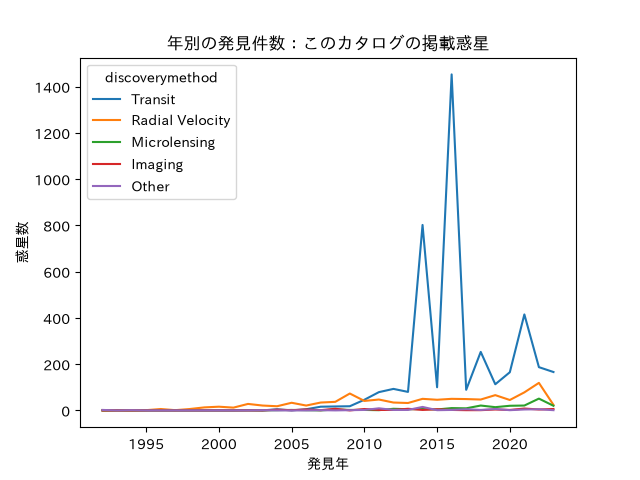

In [8]:
with phase('図表: 年別の発見件数：このカタログの掲載惑星'):
    png = render_chart(annual_plot, kind='line', title='年別の発見件数：このカタログの掲載惑星', xlabel='発見年', ylabel='惑星数')
    chart_output = build_image_output(png)
    display(chart_output['data'], raw=True)


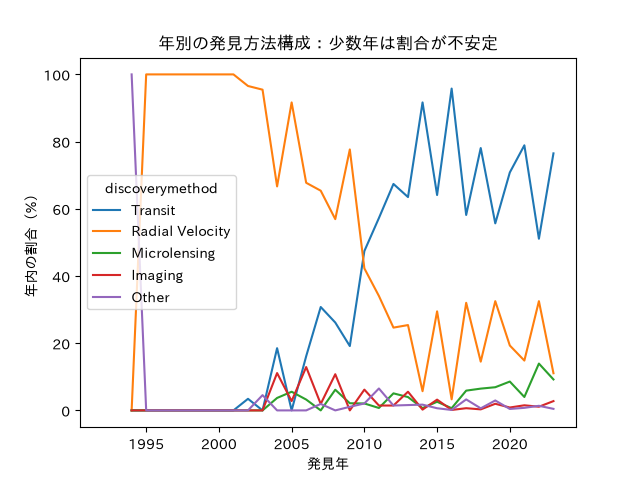

In [9]:
with phase('図表: 年別の発見方法構成：少数年は割合が不安定'):
    png = render_chart(share_plot, kind='line', title='年別の発見方法構成：少数年は割合が不安定', xlabel='発見年', ylabel='年内の割合（%）')
    chart_output = build_image_output(png)
    display(chart_output['data'], raw=True)


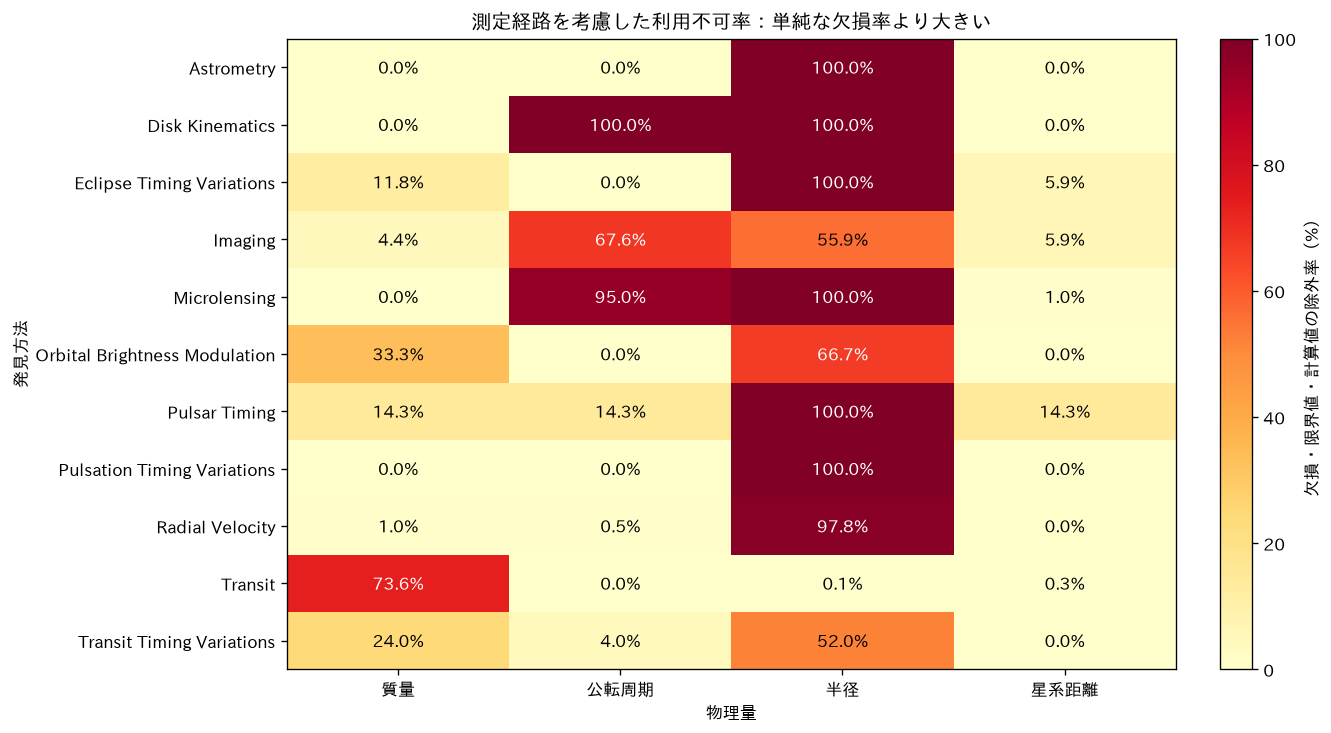

{
  "title": "測定経路を考慮した利用不可率",
  "xlabel": "物理量",
  "ylabel": "発見方法",
  "legend": [
    "色=利用不可率（%）"
  ],
  "missing_glyphs": [],
  "clipped_labels": [],
  "render_warnings": []
}

In [10]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, ft2font
chart_checks = []
def show_audited_figure(fig, title, xlabel, ylabel, legend):
    fig.canvas.draw()
    glyphs = []
    clipped = []
    renderer = fig.canvas.get_renderer()
    from matplotlib.text import Text
    width, height = fig.canvas.get_width_height()
    for artist in fig.findobj(Text):
        if not artist.get_visible() or not artist.get_text():
            continue
        font = ft2font.FT2Font(font_manager.findfont(artist.get_fontproperties()))
        glyphs.extend(ord(ch) for ch in artist.get_text() if not ch.isspace() and font.get_char_index(ord(ch)) == 0)
        bounds = artist.get_window_extent(renderer)
        if bounds.x0 < -1 or bounds.y0 < -1 or bounds.x1 > width+1 or bounds.y1 > height+1:
            clipped.append(artist.get_text())
    check = {'title': title, 'xlabel': xlabel, 'ylabel': ylabel, 'legend': legend, 'missing_glyphs': sorted(set(glyphs)), 'clipped_labels': clipped}
    chart_checks.append(check)
    assert not glyphs and not clipped, check
    buffer = io.BytesIO()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        fig.savefig(buffer, format='png', bbox_inches='tight', dpi=120)
    plt.close(fig)
    check['render_warnings'] = [str(w.message) for w in caught]
    assert not any('Glyph' in message for message in check['render_warnings'])
    display(build_image_output(buffer.getvalue())['data'], raw=True)
    json_result(check)
with phase('図表: 欠損率と計算値除外後の利用率'):
    fig, ax = plt.subplots(figsize=(11,6), layout='constrained')
    data = 100*(1-physical_summary.pivot(index='method',columns='variable',values='usable_n').div(method_counts,axis=0))
    image = ax.imshow(data.values, vmin=0, vmax=100, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(data.columns)), ['質量','公転周期','半径','星系距離'])
    ax.set_yticks(range(len(data.index)), data.index)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j,i,f'{data.iloc[i,j]:.1f}%',ha='center',va='center',color='white' if data.iloc[i,j]>60 else 'black')
    ax.set(title='測定経路を考慮した利用不可率：単純な欠損率より大きい', xlabel='物理量', ylabel='発見方法')
    fig.colorbar(image,ax=ax,label='欠損・限界値・計算値の除外率（%）')
    show_audited_figure(fig,'測定経路を考慮した利用不可率','物理量','発見方法',['色=利用不可率（%）'])


掲載惑星のTransit比率は 0.7483129673536385（約74.8%）。これは検出カタログ内の構成比であり、宇宙全体の惑星の存在頻度ではない。

```evidence
{"execution_count":7,"cited_value":"0.7483129673536385","claim_type":"descriptive"}
```

最多の2016年は 1517 惑星。時系列は滑らかな増加ではなく確認・公開バッチの影響を調べる必要がある。

```evidence
{"execution_count":7,"cited_value":"1517","claim_type":"descriptive"}
```

質量の計算値・質量半径関係による値が 2883 行ある。質量の欠損率が低くても、全行の質量を実測値として扱ってはいけない。

```evidence
{"execution_count":7,"cited_value":"2883","claim_type":"descriptive"}
```

## 反復依頼履歴

### 反復1：原文
質量・半径の欠損が少ない理由を、計算値と通常の観測値の違いから調べてください。推定値込みと推定値除外で代表値がどれだけ変わるか、質量をMass・Msini別に示し、誤差が記載された値だけに限定した感度分析も行ってください。

選定理由：初回集計で計算値が多く、欠損率だけでは実測情報の不足を表せない。質量中央値の結論が測定経路に依存する可能性がある。

In [11]:
with phase('反復1: 測定経路と利用可能性'):
    availability_rows = []
    route_rows = []
    for method in top_methods:
        method_mask = df.discoverymethod.eq(method)
        for column, calculated in [('pl_bmasse',mass_calculated), ('pl_rade',radius_calculated)]:
            observed = valid_masks[column] & method_mask
            listed = method_mask & df[column].notna() & df[column].gt(0) & df[column+'lim'].eq(0)
            uncertain = observed & df[column+'err1'].notna() & df[column+'err2'].notna()
            availability_rows.append({'method': method, 'variable': column, 'total_n': int(method_mask.sum()), 'listed_n': int(listed.sum()), 'not_calculated_n': int(observed.sum()), 'uncertainty_reported_n': int(uncertain.sum()), 'listed_median': df.loc[listed,column].median(), 'not_calculated_median': df.loc[observed,column].median(), 'uncertainty_reported_median': df.loc[uncertain,column].median()})
        for route in df.pl_bmassprov.unique():
            mask = method_mask & df.pl_bmassprov.eq(route) & valid_masks['pl_bmasse']
            route_rows.append({'method': method, 'route': route, 'n': int(mask.sum()), 'median_mass': df.loc[mask,'pl_bmasse'].median()})
    availability = pd.DataFrame(availability_rows)
    mass_routes = pd.DataFrame(route_rows)
    def transit_mass_median(only_observed, require_uncertainty):
        mask = df.discoverymethod.eq('Transit') & df.pl_bmasse.notna() & df.pl_bmasse.gt(0) & df.pl_bmasselim.eq(0)
        if only_observed:
            mask &= valid_masks['pl_bmasse']
        if require_uncertainty:
            mask &= df.pl_bmasseerr1.notna() & df.pl_bmasseerr2.notna()
        return df.loc[mask,'pl_bmasse'].median()
    route_plan = SensitivityPlan({'only_observed': [False,True], 'require_uncertainty': [False,True]}, max_runs=4)
    route_sensitivity = run_sensitivity(route_plan, transit_mass_median, stability_tolerance=.2)
    iteration1_metrics = {'availability': availability.fillna('NA').to_dict(orient='records'), 'mass_routes': mass_routes.fillna('NA').to_dict(orient='records'), 'transit_mass_sensitivity': asdict(route_sensitivity), 'transit_calculated_mass_n': int((df.discoverymethod.eq('Transit') & mass_calculated).sum()), 'rv_calculated_radius_n': int((df.discoverymethod.eq('Radial Velocity') & radius_calculated).sum())}
    json_result(iteration1_metrics)
    display(availability.round(3))
    display(mass_routes[mass_routes.n.gt(0)].round(3))


{
  "availability": [
    {
      "method": "Transit",
      "variable": "pl_bmasse",
      "total_n": 4103,
      "listed_n": 3960,
      "not_calculated_n": 1082,
      "uncertainty_reported_n": 1076,
      "listed_median": 6.39,
      "not_calculated_median": 107.266525,
      "uncertainty_reported_median": 106.236525
    },
    {
      "method": "Transit",
      "variable": "pl_rade",
      "total_n": 4103,
      "listed_n": 4101,
      "not_calculated_n": 4099,
      "uncertainty_reported_n": 3716,
      "listed_median": 2.37,
      "not_calculated_median": 2.37,
      "uncertainty_reported_median": 2.37
    },
    {
      "method": "Radial Velocity",
      "variable": "pl_bmasse",
      "total_n": 1048,
      "listed_n": 1037,
      "not_calculated_n": 1037,
      "uncertainty_reported_n": 992,
      "listed_median": 346.4347,
      "not_calculated_median": 346.4347,
      "uncertainty_reported_median": 328.95405
    },
    {
      "method": "Radial Velocity",
      "variable": "

,method,variable,total_n,listed_n,not_calculated_n,uncertainty_reported_n,listed_median,not_calculated_median,uncertainty_reported_median
0,Transit,pl_bmasse,4103,3960,1082,1076,6.390,107.267,106.237
1,Transit,pl_rade,4103,4101,4099,3716,2.370,2.370,2.370
2,Radial Velocity,pl_bmasse,1048,1037,1037,992,346.435,346.435,328.954
3,Radial Velocity,pl_rade,1048,1037,23,22,12.600,3.890,3.403
4,Microlensing,pl_bmasse,201,201,201,200,162.092,162.092,166.046
5,Microlensing,pl_rade,201,201,0,0,12.500,NaN,NaN
6,Imaging,pl_bmasse,68,66,65,60,3983.680,3972.875,3983.680
7,Imaging,pl_rade,68,66,30,26,12.600,14.572,15.412


,method,route,n,median_mass
0,Transit,Msini,1,2548.984
1,Transit,Mass,1079,108.060
2,Transit,Msin(i)/sin(i),2,5.779
4,Radial Velocity,Msini,805,209.768
5,Radial Velocity,Mass,217,1880.909
6,Radial Velocity,Msin(i)/sin(i),15,21.400
9,Microlensing,Mass,201,162.092
13,Imaging,Mass,65,3972.875


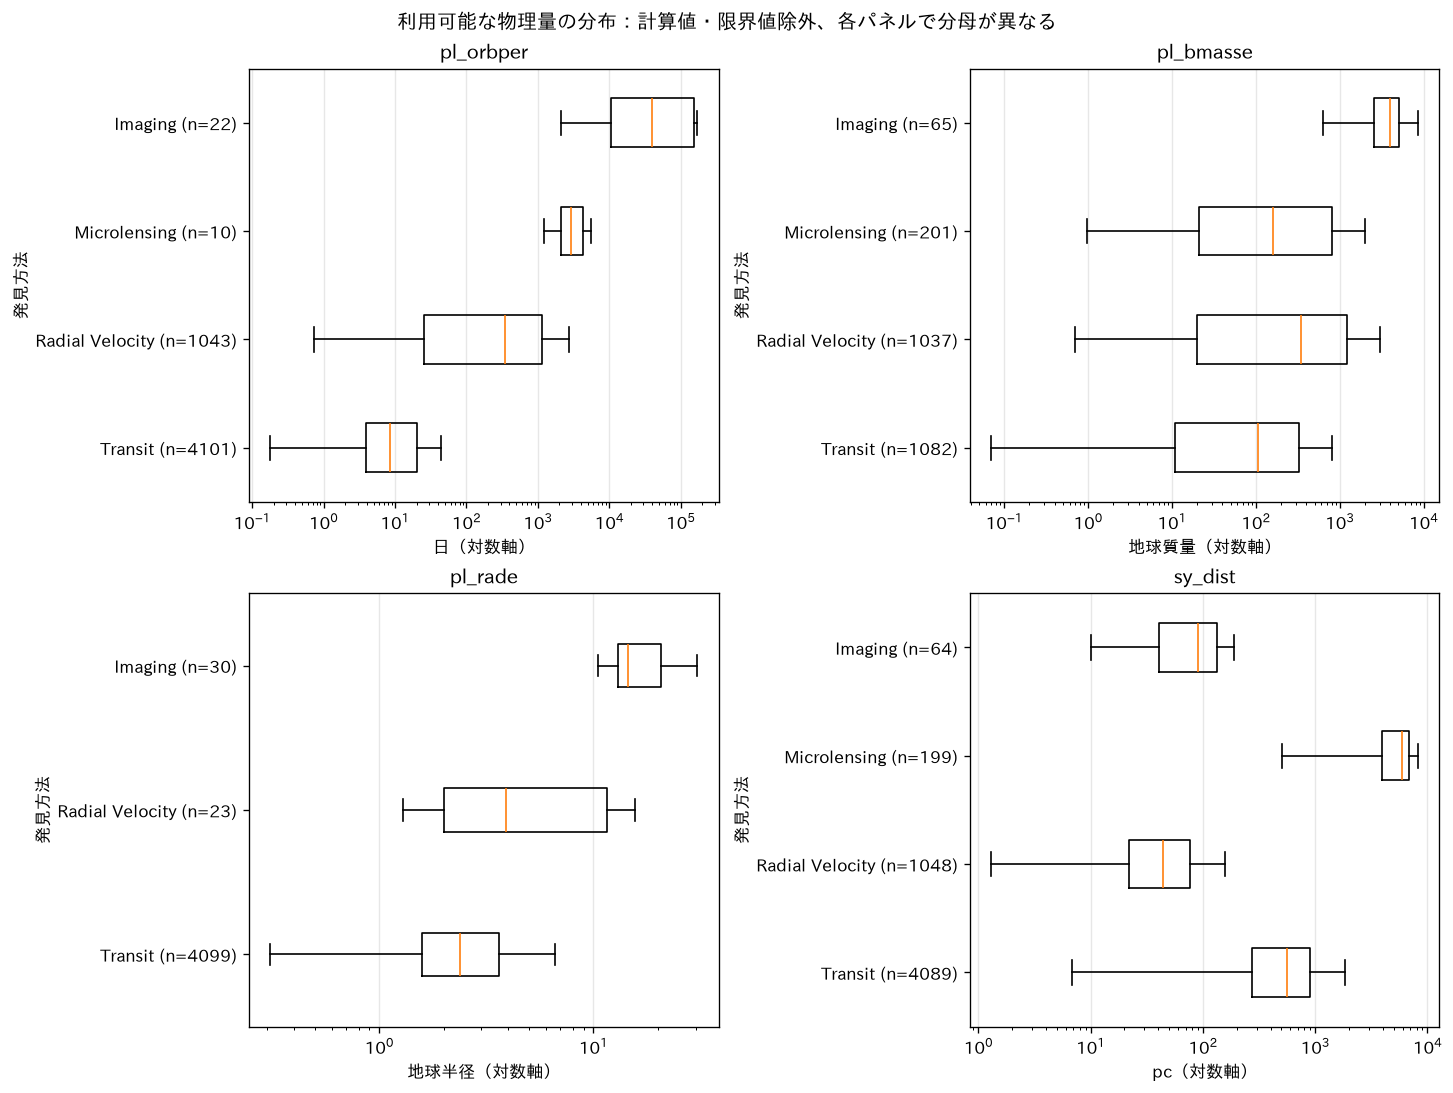

{
  "title": "方法別の物理量分布",
  "xlabel": "各物理量（対数軸）",
  "ylabel": "発見方法",
  "legend": [
    "箱=四分位範囲、線=中央値、ひげ=1.5IQR、外れ点非表示"
  ],
  "missing_glyphs": [],
  "clipped_labels": [],
  "render_warnings": []
}

In [12]:
with phase('図表: 方法別の物理量分布'):
    fig, axes = plt.subplots(2,2,figsize=(12,9),layout='constrained')
    labels = {'Transit':'Transit','Radial Velocity':'Radial Velocity','Microlensing':'Microlensing','Imaging':'Imaging'}
    for ax,column,unit in zip(axes.flat,['pl_orbper','pl_bmasse','pl_rade','sy_dist'],['日','地球質量','地球半径','pc']):
        selected = [(m,df.loc[df.discoverymethod.eq(m)&valid_masks[column],column]) for m in top_methods]
        selected = [(m,s) for m,s in selected if len(s)>=10]
        ax.boxplot([s for m,s in selected], orientation='horizontal', tick_labels=[f'{labels[m]} (n={len(s)})' for m,s in selected], showfliers=False)
        ax.set_xscale('log')
        lo,hi = ax.get_xlim()
        ticks = 10.0**np.arange(np.ceil(np.log10(lo)),np.floor(np.log10(hi))+1)
        ax.set_xticks(ticks)
        ax.set(title=column, xlabel=unit+'（対数軸）', ylabel='発見方法')
        ax.grid(axis='x',alpha=.3)
    fig.suptitle('利用可能な物理量の分布：計算値・限界値除外、各パネルで分母が異なる')
    show_audited_figure(fig,'方法別の物理量分布','各物理量（対数軸）','発見方法',['箱=四分位範囲、線=中央値、ひげ=1.5IQR、外れ点非表示'])


反復1の結果：Transitの質量中央値は推定値込み6.39、計算値除外107.266525、誤差記載あり106.236525地球質量。4仕様の感度分析はstable=False、最大相対変動 15.786623630672928。約16.8倍の差は推定値と追観測対象選択の影響であり、「Transit惑星全体が実測でもこの質量」とは言えない。残る限界：Massも動力学・進化モデルなど異なる測定経路を含み、全惑星の真の質量分布を復元できない。

```evidence
{"execution_count":11,"cited_value":"15.786623630672928","claim_type":"descriptive"}
```

### 反復2：原文
2014年・2016年の発見件数の急増が、特定の観測施設や一括公開に集中しているか調べてください。発見時期をそろえた方法別の周期・距離比較も行い、最終年と急増年を除いてもTransit中心という結論が保たれるか確認してください。

選定理由：初回で2016年に1517件が集中した。発見年の差と施設構成が周期・距離の方法差と交絡している可能性がある。

In [13]:
with phase('反復2: 時代・施設・公開集中の比較'):
    df['era'] = pd.cut(df.disc_year, bins=[1991,2009,2013,2017,2022,2023], labels=['1992-2009','2010-2013','2014-2017','2018-2022','2023'])
    era_counts = pd.crosstab(df.era,df.discoverymethod).reindex(columns=annual_plot.columns[:-1],fill_value=0)
    era_counts['Other'] = pd.crosstab(df.era,df.discoverymethod).drop(columns=top_methods).sum(axis=1)
    era_shares = era_counts.div(era_counts.sum(axis=1),axis=0)*100
    facility_records = []
    for year in [2014,2016,2021,2022,2023]:
        group = df[df.disc_year.eq(year)]
        counts = group.disc_facility.fillna('unknown').value_counts()
        facility_records.append({'year':year,'total_n':len(group),'top_facility':counts.index[0],'top_n':int(counts.iloc[0]),'top_share':float(counts.iloc[0]/len(group)), 'transit_n':int(group.discoverymethod.eq('Transit').sum())})
    era_physical_rows = []
    for era in df.era.cat.categories:
        for method in ['Transit','Radial Velocity']:
            for column in ['pl_orbper','sy_dist']:
                mask = df.era.eq(era) & df.discoverymethod.eq(method) & valid_masks[column]
                values = df.loc[mask,column]
                era_physical_rows.append({'era':str(era),'method':method,'variable':column,'n':len(values),'median':values.median()})
    era_physical = pd.DataFrame(era_physical_rows)
    def transit_share_spec(start_year, exclude_burst, exclude_last):
        mask = df.disc_year.ge(start_year)
        if exclude_burst:
            mask &= ~df.disc_year.isin([2014,2016])
        if exclude_last:
            mask &= df.disc_year.lt(df.disc_year.max())
        return df.loc[mask,'discoverymethod'].eq('Transit').mean()
    time_plan = SensitivityPlan({'start_year':[2010,2014,2018], 'exclude_burst':[False,True], 'exclude_last':[False,True]},max_runs=12)
    time_sensitivity = run_sensitivity(time_plan,transit_share_spec,stability_tolerance=.2)
    iteration2_metrics = {'facility_peaks':facility_records,'era_counts':era_counts.to_dict(),'era_shares':era_shares.to_dict(), 'era_physical':era_physical.fillna('NA').to_dict(orient='records'), 'time_sensitivity':asdict(time_sensitivity),'all_specifications_transit_majority':all(r.value>.5 for r in time_sensitivity.results), 'latest_publication_month':str(df.disc_pubdate.max())}
    json_result(iteration2_metrics)
    display(pd.DataFrame(facility_records))
    display(era_counts)
    display(era_physical)


{
  "facility_peaks": [
    {
      "year": 2014,
      "total_n": 875,
      "top_facility": "Kepler",
      "top_n": 785,
      "top_share": 0.8971428571428571,
      "transit_n": 802
    },
    {
      "year": 2016,
      "total_n": 1517,
      "top_facility": "Kepler",
      "top_n": 1282,
      "top_share": 0.8450889914304548,
      "transit_n": 1453
    },
    {
      "year": 2021,
      "total_n": 526,
      "top_facility": "Kepler",
      "top_n": 310,
      "top_share": 0.5893536121673004,
      "transit_n": 415
    },
    {
      "year": 2022,
      "total_n": 366,
      "top_facility": "Transiting Exoplanet Survey Satellite (TESS)",
      "top_n": 109,
      "top_share": 0.2978142076502732,
      "transit_n": 187
    },
    {
      "year": 2023,
      "total_n": 217,
      "top_facility": "Transiting Exoplanet Survey Satellite (TESS)",
      "top_n": 90,
      "top_share": 0.4147465437788018,
      "transit_n": 166
    }
  ],
  "era_counts": {
    "Transit": {
      "1992-20

,year,total_n,top_facility,top_n,top_share,transit_n
0,2014,875,Kepler,785,0.897143,802
1,2016,1517,Kepler,1282,0.845089,1453
2,2021,526,Kepler,310,0.589354,415
3,2022,366,Transiting Exoplanet Survey Satellite (TESS),109,0.297814,187
4,2023,217,Transiting Exoplanet Survey Satellite (TESS),90,0.414747,166


discoverymethod,Transit,Radial Velocity,Microlensing,Imaging,Other
era,,,,,
1992-2009,62,320,10,16,6
2010-2013,298,154,15,17,15
2014-2017,2444,195,29,10,23
2018-2022,1133,355,127,19,18
2023,166,24,20,6,1


,era,method,variable,n,median
0,1992-2009,Transit,pl_orbper,62,3.155070
1,1992-2009,Transit,sy_dist,62,279.151000
2,1992-2009,Radial Velocity,pl_orbper,320,387.149995
3,1992-2009,Radial Velocity,sy_dist,320,40.884900
4,2010-2013,Transit,pl_orbper,298,7.898471
5,2010-2013,Transit,sy_dist,298,432.049500
6,2010-2013,Radial Velocity,pl_orbper,154,423.200000
7,2010-2013,Radial Velocity,sy_dist,154,52.253850
8,2014-2017,Transit,pl_orbper,2442,10.004973
9,2014-2017,Transit,sy_dist,2444,690.928000


反復2の結果：2014年のKepler掲載785/875件、2016年は1282/1517件。施設集中は一括公開・確認の影響と整合的だが、カタログだけで発生機序は確定できない。開始年・急増年除外・最終年除外の12仕様でTransit比率は65.9–82.2%、stable=True、最大相対変動 0.1739366614156119（事前許容20%）。同じ時代でもTransitの周期が短く、星系距離は長い方向が保たれた。残る限界：観測時間・検出効率・未検出対象の母数がなく、効率や存在頻度は評価できない。

```evidence
{"execution_count":13,"cited_value":"0.1739366614156119","claim_type":"descriptive"}
```

### 反復3：原文
同じ主星に複数惑星が含まれることと、全物理量が揃った完全ケースへの限定が、方法別の周期比較をゆがめないか調べてください。主星ごとの中央値を等重みで扱う場合、時期を変えた場合、両端1%を除く場合を比較し、結論の方向と大きさの安定性を別々に報告してください。

選定理由：同時期でも方法差は残ったが、複数惑星系を繰り返し数える重みと、測定済み半径がある少数RV惑星への完全ケース限定が結論を変える懸念が残る。

In [14]:
with phase('反復3: 主星単位・完全ケース・外れ値の感度'):
    complete_mask = pd.Series(True,index=df.index)
    for column in ['pl_orbper','pl_bmasse','pl_rade','sy_dist']:
        complete_mask &= valid_masks[column]
    specification_details = []
    def period_ratio_spec(start_year, complete_case, host_balanced, trim):
        base = df.disc_year.ge(start_year) & df.disc_year.lt(df.disc_year.max()) & valid_masks['pl_orbper']
        if complete_case:
            base &= complete_mask
        medians = {}
        counts = {}
        for method in ['Transit','Radial Velocity']:
            subset = df.loc[base & df.discoverymethod.eq(method), ['hostname','pl_orbper']].copy()
            if trim > 0:
                lo,hi = subset.pl_orbper.quantile([trim,1-trim])
                subset = subset[subset.pl_orbper.between(lo,hi)]
            series = subset.groupby('hostname').pl_orbper.median() if host_balanced else subset.pl_orbper
            if len(series)<10:
                raise ValueError('感度仕様の利用可能対象が10未満')
            medians[method] = float(series.median())
            counts[method] = {'planets':len(subset),'hosts':subset.hostname.nunique(),'analysis_n':len(series)}
        ratio = medians['Radial Velocity']/medians['Transit']
        specification_details.append({'start_year':start_year,'complete_case':complete_case,'host_balanced':host_balanced,'trim':trim,'median_days':medians,'counts':counts,'rv_transit_ratio':ratio})
        return ratio
    unit_plan = SensitivityPlan({'start_year':[1992], 'complete_case':[False,True], 'host_balanced':[False,True], 'trim':[0,.01]},max_runs=8)
    unit_sensitivity = run_sensitivity(unit_plan,period_ratio_spec,stability_tolerance=.2)
    era_unit_plan = SensitivityPlan({'start_year':[2010,2018], 'complete_case':[False], 'host_balanced':[False,True], 'trim':[0,.01]},max_runs=8)
    era_unit_sensitivity = run_sensitivity(era_unit_plan,period_ratio_spec,stability_tolerance=.2)
    complete_by_method = df.groupby('discoverymethod').size().rename('total_n').to_frame()
    complete_by_method['complete_n'] = df[complete_mask].groupby('discoverymethod').size().reindex(complete_by_method.index,fill_value=0)
    complete_by_method['retained_pct'] = complete_by_method.complete_n/complete_by_method.total_n*100
    variable_case_ratios = [r.value for r in unit_sensitivity.results + era_unit_sensitivity.results if not r.specification['complete_case']]
    complete_ratios = [r.value for r in unit_sensitivity.results if r.specification['complete_case']]
    iteration3_metrics = {'sensitivity':asdict(unit_sensitivity),'era_unit_sensitivity':asdict(era_unit_sensitivity),'excluded_specifications': '2010年以降・2018年以降の完全ケースと1%除外・主星等重みを同時適用するとRV主星が10未満。完全ケースの感度は全期間に限定し、最近期は変数別利用可能ケースのみ検査。' ,'specification_details':specification_details, 'complete_by_method':complete_by_method.to_dict(),'variable_case_direction_consistent':all(value>1 for value in variable_case_ratios), 'variable_case_ratio_range':[min(variable_case_ratios),max(variable_case_ratios)], 'complete_case_ratio_range':[min(complete_ratios),max(complete_ratios)], 'complete_case_direction_consistent':all(value>1 for value in complete_ratios)}
    json_result(iteration3_metrics)
    display(complete_by_method.round(2))
    display(pd.DataFrame(specification_details)[['start_year','complete_case','host_balanced','trim','rv_transit_ratio']].round(4))


{
  "sensitivity": {
    "results": [
      {
        "specification": {
          "start_year": 1992,
          "complete_case": false,
          "host_balanced": false,
          "trim": 0
        },
        "value": 40.35949645550015
      },
      {
        "specification": {
          "start_year": 1992,
          "complete_case": false,
          "host_balanced": false,
          "trim": 0.01
        },
        "value": 40.35949645550015
      },
      {
        "specification": {
          "start_year": 1992,
          "complete_case": false,
          "host_balanced": true,
          "trim": 0
        },
        "value": 56.00377260452575
      },
      {
        "specification": {
          "start_year": 1992,
          "complete_case": false,
          "host_balanced": true,
          "trim": 0.01
        },
        "value": 54.73450993673525
      },
      {
        "specification": {
          "start_year": 1992,
          "complete_case": true,
          "host_balanced": f

,total_n,complete_n,retained_pct
discoverymethod,,,
Astrometry,2,0,0.00
Disk Kinematics,1,0,0.00
Eclipse Timing Variations,17,0,0.00
Imaging,68,11,16.18
Microlensing,201,0,0.00
Orbital Brightness Modulation,9,3,33.33
Pulsar Timing,7,0,0.00
Pulsation Timing Variations,2,0,0.00
Radial Velocity,1048,23,2.19


,start_year,complete_case,host_balanced,trim,rv_transit_ratio
0,1992,False,False,0.00,40.3595
1,1992,False,False,0.01,40.3595
2,1992,False,True,0.00,56.0038
3,1992,False,True,0.01,54.7345
4,1992,True,False,0.00,1.4696
5,1992,True,False,0.01,1.4696
6,1992,True,True,0.00,1.1966
7,1992,True,True,0.01,1.3428
8,2010,False,False,0.00,32.3561
9,2010,False,False,0.01,32.3561


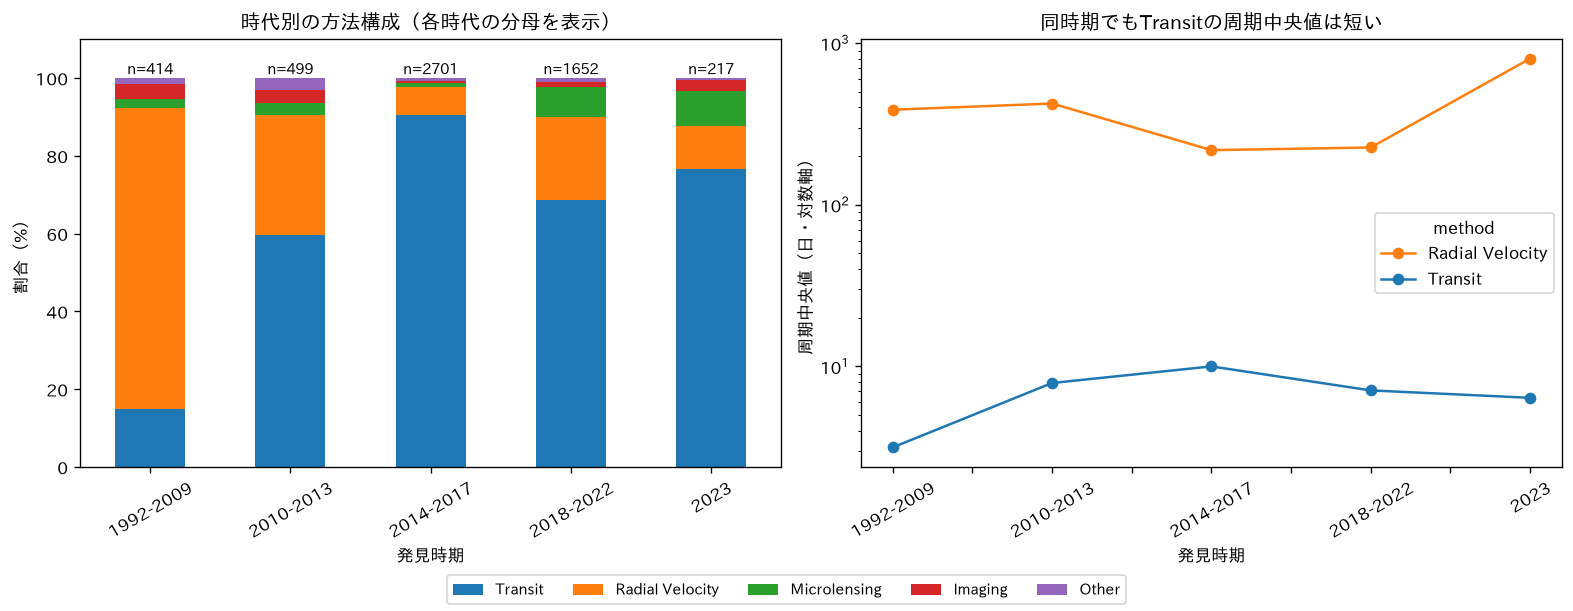

{
  "title": "時代別の方法構成と周期",
  "xlabel": "発見時期",
  "ylabel": "割合（%）／周期（日）",
  "legend": [
    "発見方法"
  ],
  "missing_glyphs": [],
  "clipped_labels": [],
  "render_warnings": []
}

In [15]:
with phase('図表: 時代別の方法構成と周期比較'):
    fig, axes = plt.subplots(1,2,figsize=(13,5),layout='constrained')
    era_shares.plot(kind='bar',stacked=True,ax=axes[0],rot=30)
    axes[0].set(title='時代別の方法構成（各時代の分母を表示）',xlabel='発見時期',ylabel='割合（%）')
    handles,legend_labels = axes[0].get_legend_handles_labels()
    axes[0].get_legend().remove()
    fig.legend(handles,legend_labels,loc='outside lower center',ncol=5,fontsize=9)
    for i,n in enumerate(era_counts.sum(axis=1)):
        axes[0].text(i,101,f'n={n}',ha='center',fontsize=9)
    axes[0].set_ylim(0,110)
    axes[0].set_yticks([0,20,40,60,80,100])
    table = era_physical[era_physical.variable.eq('pl_orbper')].pivot(index='era',columns='method',values='median').reindex(df.era.cat.categories)
    table.plot(marker='o',ax=axes[1],logy=True,color=['#ff7f0e','#1f77b4'])
    axes[1].set(title='同時期でもTransitの周期中央値は短い',xlabel='発見時期',ylabel='周期中央値（日・対数軸）')
    axes[1].tick_params(axis='x',rotation=30)
    lo,hi = axes[1].get_ylim()
    axes[1].set_yticks(10.0**np.arange(np.ceil(np.log10(lo)),np.floor(np.log10(hi))+1))
    show_audited_figure(fig,'時代別の方法構成と周期','発見時期','割合（%）／周期（日）',['発見方法'])


In [16]:
from ai_data_scientist.notebook_audit import audit_visual_outputs
with phase('Jupytermind改善候補の再現確認'):
    existing_nb = nbformat.read(handle.notebook_path,as_version=4)
    source_chart = next(cell for cell in existing_nb.cells if cell.cell_type=='code' and any('image/png' in o.get('data',{}) for o in cell.outputs))
    probe_cell = nbformat.v4.new_code_cell('# メタデータ欠落の監査プローブ')
    probe_cell.outputs = [o for o in source_chart.outputs if 'image/png' in o.get('data',{})]
    probe_nb = nbformat.v4.new_notebook(cells=[probe_cell])
    metadata_probe_findings = audit_visual_outputs(probe_nb,(0,))
    improvement_probe = {'missing_chart_metadata':True,'actual_visual_findings':[asdict(f) for f in metadata_probe_findings], 'expected':'title/xlabel/ylabel/legend/glyph検査情報が未記録であることを警告する', 'classification':'監査機能不足', 'scope':'Jupytermind notebook_audit、Kaggle APIやCLIとは独立'}
    json_result(improvement_probe)


{
  "missing_chart_metadata": true,
  "actual_visual_findings": [],
  "expected": "title/xlabel/ylabel/legend/glyph検査情報が未記録であることを警告する",
  "classification": "監査機能不足",
  "scope": "Jupytermind notebook_audit、Kaggle APIやCLIとは独立"
}

反復3の結果：変数別ケースではRV/Transitの周期中央値比は31.819–73.139。完全ケースでは1.197–1.470に縮小し、RVは1048惑星中23惑星だけが残る。全期間8仕様のstable=False、最大相対変動 0.9703519129883675。最近期8仕様もstable=False（最大相対変動1.2604460964662973）。方向は今回の16仕様で同じでも、差の大きさは頑健ではない。主解析は変数別ケースとし、完全ケースを宇宙の一般分布へ外挿しない。残る限界：主星内中央値は惑星の存在頻度の重み補正ではなく、最近期完全ケースは標本不足で不適用。

```evidence
{"execution_count":14,"cited_value":"0.9703519129883675","claim_type":"descriptive"}
```

惑星特性の主比較：Transitの周期中央値は 8.483 日（n=4101）、RVは352.2日（n=1043）。星系距離はTransit 555.134 pc（n=4089）、RV 43.8214 pc（n=1048）、Microlensing 5900 pc（n=199）。半径中央値はTransit 2.37地球半径（n=4099）だが、RVの非計算半径は23件のみ。これは方法の検出選択と追観測の違いを反映する記述比較であり、方法を変更した因果効果ではない。

```evidence
{"execution_count":7,"cited_value":"8.483","claim_type":"descriptive"}
```

## 使用したJupytermindモジュール

以下は直接import・呼び出したものだけを列挙する（間接依存は除外）。セル番号は0始まり。

| モジュール | 直接呼び出した関数・クラス | 目的・セル |
|---|---|---|
| ai_data_scientist.project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 保存先固定・Notebook著作の直列化、セル1とJupyter MCP著作補助セル |
| ai_data_scientist.language_router | detect_language | 日本語判定、セル1 |
| ai_data_scientist.lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_failed, mark_completed, get_run_status, wait_for_quiescence | 実行・書込み・完了の追跡、セル1と各phase・最終セル |
| ai_data_scientist.ingestion | SourceSpec, ingest | 原本CSVの読込みと行数上限、セル7 |
| ai_data_scientist.cleaning | clean_dataset | 完全重複の有無と除去影響を記録、セル7 |
| ai_data_scientist.eda | explore | 欠損・型・カテゴリの要約、セル7 |
| ai_data_scientist.data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 出典・単位・定義の確実性、セル6 |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 記述範囲と未解決前提、セル7・最終セル |
| ai_data_scientist.data_quality | detect_anomalies | 宣言的な範囲・カテゴリ・欠損・一意性検査、セル7 |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 測定経路4仕様、時間窓12仕様、観測単位8+8仕様、セル17・21・24 |
| ai_data_scientist.visualization | render_chart, build_image_output | 日本語時系列PNG・MIME画像保存、セル10・11・12・18・25 |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight | 実行出力から数値を抽出し根拠付きInsight保存、Jupyter MCP著作補助セル・最終セル |
| ai_data_scientist.notebook_audit | audit_visual_outputs, audit_notebook | 画像監査プローブと最終visual_audit=True、セル26・最終セル |

## 不適用機能・代替経路

- mcp_gateway.run_and_record：ホスト側MCP client.executeアダプタがこのツール接続にないため直接は呼ばない。カーネルから同じカーネルへ再入実行すると待合せになるため、実際のJupyter MCP execute_cellを使い、実行結果・execution_countはサーバーが保存する。ローカルexecや偽クライアントでの代用はしない。
- stats_analysis.correlation：方法はカテゴリであり、全方法を混ぜた相関は観測選択・推定値を混同する。今回の問いには層別分布・中央値・感度分析を用いる。
- anomaly_detectionのz-score：物理量は桁にまたがる裾の長い分布で、珍しい天体は直ちに誤記ではない。意味的な制約と非有限・非正値・限界フラグを検査する。
- data_quality.validate_anomalies / dataset_validation.compare_datasets：独立に取得済みの第二カタログや照合キーをユーザーは指定していない。辞書は独立の惑星データではない。同じNASA複合表の別配布を独立検証と偽らない。
- 欠損補完・因果推論・検出効率補正：観測対象母集団、観測期間、検出確率、測定誤差の統一モデルがないため不適用。
- 指定公開CSVフォールバック：Kaggle取得が成功したので使用していない。

## Jupytermind改善候補

| 分類 | 再現条件 | 期待する挙動 | 実際の挙動 | 影響 | 回避策 | 関係セル・ログ |
|---|---|---|---|---|---|---|
| 可視化の可読性不足 | render_chart(kind='bar')で11種類の長い発見方法ラベルを描く | ラベル全体が画像内に収まる | 初回棒図の下端ラベルが切れた。固定figsize・余白自動調整なし | 方法名が読み取れない | constrained layout付き横方向ヒートマップに置換、フォントと文字領域を検査 | 初回セル12の棒図（置換前）、現在セル12のchart_checks |
| 監査機能不足 | image/pngがあるセルのmetadata.chartを空にする | タイトル・軸・凡例・glyph検査結果が未記録なら指摘 | audit_visual_outputsが空タプルを返す。セル26で再現 | メタデータがない画像を問題なしとして通しうる | 全図に明示メタデータを付与、文字欠落と切れを追加検査 | セル26 improvement_probe、最終audit_report |

これらはJupytermind関数で再現し、Copilot CLI・Kaggle API・ベンチマークランナー固有ではない。初回図の追加クリッピング検査で軸範囲外の未描画目盛まで数えた問題、bootstrapのNameError、最近期完全ケースの標本不足は本分析の著作・仕様選択の問題であり、Jupytermind不具合とは分類しない。最終再実行前に修正し、初回履歴は実行ログに残す。

## 反復の終了判断・残る限界

3回の追加依頼を実施。測定経路、公開集中、時代、主星重み、完全ケース選択を確認した。残る不確実性は検出母集団・観測効率・厳密なカタログ更新時点・複合値の自己整合性に由来し、同じCSVをさらに加工しても解決できないため、ここで追加分析を終了する。ライセンス未確認につき再配布の許諾は主張しない。現在の宇宙全体・2026年の全発見状況を表すデータではなく、最終発見年は2023年、発行月最大は2023-08である。最終年の減少を能力低下と読まない。


### Notebook書込みとライブ実行の連携：追加候補
分類：連携仕様不足（帰属未確定）。再現条件：実行中のセル32から同じNotebookにenqueue_writeを行う。期待：markdownの根拠だけを同期し、実行中セルの出力・execution_countを保存。実際：処理とsidecar書込みは完了したが、MCP read_notebookでは当該セルのexecution_countがNoneで出力も空になった。影響：監査セルが未実行に見える。回避策：根拠同期を別のJupyter MCP著作補助Notebookから実施し、最終セルでは変更不要なら書かない。関係セル：32、初回execution-log.jsonとinitial-execution-log.json、MCP read_notebook。Jupytermindのファイル書込みとJupyter MCPのライブ文書同期との連携候補であり、根本原因は未確定。CLI・Kaggle認証・ベンチマークランナーとは切り分ける。


著作補助ノートの実行済み記録は `../data/authoring-record.ipynb` に保存。ProjectHandleもこの補助記録の保存先指定に直接使用した。


In [17]:
with phase('結果固定・再実行照合・最終manifest'):
    final_assumptions = AnalysisAssumptionManifest(analysis_scope={'target':'掲載惑星の記述比較', 'main':'変数別利用可能ケース', 'sensitivity_tolerance':.2}, assumptions=(Assumption('planet-row','惑星名一意・複合表の1行1惑星','tested',conclusion_critical=True), Assumption('units','使用列の単位と名称を公式NASA辞書で確認','verified',conclusion_critical=True), Assumption('selection','質量経路・時代・観測単位を変えると結論の大きさが変化する','tested',conclusion_critical=True),Assumption('snapshot-incomplete','2023年は途中集計の可能性','assumed',impact_if_false='直近の減少を能力低下と解釈しない',conclusion_critical=True)),causal_scope='descriptive')
    final_findings = check_manifest(final_assumptions)
    result_payload = {'source_sha256':provenance['sha256'], 'initial':initial_metrics,'iteration1':iteration1_metrics,'iteration2':iteration2_metrics,'iteration3':iteration3_metrics}
    canonical = json.dumps(result_payload,ensure_ascii=False,sort_keys=True,default=str,allow_nan=False)
    result_digest = hashlib.sha256(canonical.encode()).hexdigest()
    baseline_path = data_dir / 'result-baseline.json'
    if baseline_path.exists():
        baseline = json.loads(baseline_path.read_text(encoding='utf-8'))
        assert result_digest==baseline['sha256'], '再実行で数値結果が変化した'
        reproducibility = {'mode':'再実行','identical_numeric_results':True,'sha256':result_digest}
    else:
        with phase('初回数値結果の書込み',write=True):
            baseline_path.write_text(json.dumps({'sha256':result_digest,'results':result_payload},ensure_ascii=False,indent=2,default=str,allow_nan=False),encoding='utf-8')
        reproducibility = {'mode':'初回基準値作成','sha256':result_digest}
    json_result({'再現性':reproducibility,'final_assumptions':asdict(final_assumptions),'指摘':[asdict(f) for f in final_findings], 'chart_checks':chart_checks})


{
  "再現性": {
    "mode": "再実行",
    "identical_numeric_results": true,
    "sha256": "ee7189afa1bfa2b24588cba27b9612b69acb0e32b9f2be097be68b8e76bd63c9"
  },
  "final_assumptions": {
    "analysis_scope": {
      "target": "掲載惑星の記述比較",
      "main": "変数別利用可能ケース",
      "sensitivity_tolerance": 0.2
    },
    "assumptions": [
      {
        "id": "planet-row",
        "statement": "惑星名一意・複合表の1行1惑星",
        "status": "tested",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": true
      },
      {
        "id": "units",
        "statement": "使用列の単位と名称を公式NASA辞書で確認",
        "status": "verified",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": true
      },
      {
        "id": "selection",
        "statement": "質量経路・時代・観測単位を変えると結論の大きさが変化する",
        "status": "tested",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": true
      },
      {
        "id"

## 再実行・Notebook監査・ライフサイクル

原本と数値結果のハッシュを照合する。最後のセルはセルIDに基づいて根拠の実行番号を更新し、visual_audit=Trueで監査する。再実行ではAPI検索も再呼び出すが、分析対象のバイト列は初回取得ファイルへ固定する。

保存後の読取り専用監査：全コード18/18実行済み、図表5、根拠付きInsight 7、未実行・エラー・画像指摘0。数値結果SHA-256は `ee7189afa1bfa2b24588cba27b9612b69acb0e32b9f2be097be68b8e76bd63c9` で初回と一致。run_id `v020-exp-21` は completed、実行中セル・保留書込み・ロック0。


In [21]:
import re
# 安定したセルIDを使い、再実行で変わるexecution_countへの根拠参照を同期する。
with phase('根拠manifestの同期',write=True):
    def synchronize_evidence(nb):
        by_id = {cell.id:cell for cell in nb.cells}
        for cell in nb.cells:
            evidence_id = cell.get('metadata',{}).get('evidence_cell_id')
            if not evidence_id:
                continue
            evidence_cell = by_id[evidence_id]
            matched = re.search(r'```evidence\n(.*?)\n```',cell.source,re.DOTALL)
            if matched is None:
                raise ValueError('根拠manifestなし')
            manifest = json.loads(matched.group(1))
            output = '\n'.join(str(v) for out in evidence_cell.outputs for v in out.get('data',{}).values())
            cited = extract_cited_value({'output':output},re.escape(manifest['cited_value']))
            manifest['execution_count'] = evidence_cell.execution_count
            manifest['cited_value'] = cited
            cell.source = cell.source[:matched.start()]+'```evidence\n'+json.dumps(manifest,separators=(',',':'))+'\n```'+cell.source[matched.end():]
    preview_before = nbformat.read(handle.notebook_path,as_version=4)
    preview_after = nbformat.reads(nbformat.writes(preview_before),as_version=4)
    synchronize_evidence(preview_after)
    evidence_changed = any(a.source!=b.source for a,b in zip(preview_before.cells,preview_after.cells))
    if evidence_changed:
        pm.enqueue_write(handle,synchronize_evidence)
with phase('Notebook最終監査'):
    audit_report = audit_notebook(handle.notebook_path,visual_audit=True)
    json_result({'notebook_audit':asdict(audit_report),'ok':audit_report.ok,'再現性':reproducibility})
    if not audit_report.ok:
        raise RuntimeError('Notebook監査に未解決の問題がある')
lc.mark_completed(RUN_ID)
quiescent = lc.wait_for_quiescence(RUN_ID,timeout_s=10)
assert quiescent.state=='completed' and quiescent.active_cell_executions==0 and quiescent.pending_notebook_writes==0 and quiescent.locks_held==0
with phase('監査・ライフサイクルログ書込み',write=True):
    (data_dir/'execution-log.json').write_text(json.dumps({'run_id':RUN_ID,'phases':phase_log,'audit':asdict(audit_report),'audit_ok':audit_report.ok,'reproducibility':reproducibility,'status':asdict(quiescent)},ensure_ascii=False,indent=2,default=str),encoding='utf-8')
json_result({'lifecycle':asdict(lc.get_run_status(RUN_ID))})


{
  "notebook_audit": {
    "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-21-planets/notebooks/kaggle-v020-kaggle-exp-21-planets.ipynb",
    "nbformat_valid": true,
    "code_cell_count": 18,
    "executed_code_cell_count": 17,
    "unexecuted_cell_indices": [],
    "error_cell_indices": [],
    "chart_cell_indices": [
      10,
      11,
      12,
      18,
      25
    ],
    "insight_cell_count": 7,
    "findings": [
      {
        "severity": "warning",
        "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
        "cell_index": 32
      }
    ],
    "visual_findings": []
  },
  "ok": true,
  "再現性": {
    "mode": "再実行",
    "identical_numeric_results": true,
    "sha256": "ee7189afa1bfa2b24588cba27b9612b69acb0e32b9f2be097be68b8e76bd63c9"
  }
}

{
  "lifecycle": {
    "run_id": "v020-exp-21",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-21-planets/notebooks/kaggle-v020-kaggle-exp-21-planets.ipynb",
    "reason": null
  }
}